In [1]:
using Pkg
Pkg.activate("/global/homes/j/jgmorawe/desi-emulators-pipeline")

  Activating project at `~/desi-emulators-pipeline`


In [2]:
using Capse
using AbstractCosmologicalEmulators
using PyCall
using Plots
using NPZ
using DelimitedFiles
using DataInterpolations

In [3]:
# Loads the different emulator components
home_dir = "/global/homes/j/jgmorawe/desi-emulators-pipeline"
TT_emu = Capse.load_emulator(home_dir * "/trained_capse_class_mnuw0wacdm_10000/TT/")
TE_emu = Capse.load_emulator(home_dir * "/trained_capse_class_mnuw0wacdm_10000/TE/")
EE_emu = Capse.load_emulator(home_dir * "/trained_capse_class_mnuw0wacdm_10000/EE/")
l_vec = npzread(home_dir * "/trained_capse_class_mnuw0wacdm_10000/TT/l.npy")

┌ Warning: Large layer size expansion detected: Layer 5 (32) → Layer 6 (9998) (ratio: 312.44). This may cause increased memory usage, potential overfitting, or training instability.
└ @ AbstractCosmologicalEmulators ~/.julia/packages/AbstractCosmologicalEmulators/r2B3H/src/utils.jl:341
┌ Warning: Large layer size expansion detected: Layer 5 (32) → Layer 6 (9998) (ratio: 312.44). This may cause increased memory usage, potential overfitting, or training instability.
└ @ AbstractCosmologicalEmulators ~/.julia/packages/AbstractCosmologicalEmulators/r2B3H/src/utils.jl:341
┌ Warning: Large layer size expansion detected: Layer 5 (32) → Layer 6 (9998) (ratio: 312.44). This may cause increased memory usage, potential overfitting, or training instability.
└ @ AbstractCosmologicalEmulators ~/.julia/packages/AbstractCosmologicalEmulators/r2B3H/src/utils.jl:341


9998-element Vector{Int64}:
    2
    3
    4
    5
    6
    7
    8
    9
   10
   11
   12
   13
   14
    ⋮
 9988
 9989
 9990
 9991
 9992
 9993
 9994
 9995
 9996
 9997
 9998
 9999

In [4]:
# Picks a certain set of parameters
ln10As, ns, H0, ombh2, omch2, tau, Mnu, w0, wa = 2.8, 1.02, 59, 0.0235, 0.15, 0.05, 0.06, -0.7, -0.9
emulator_input = [ln10As, ns, H0, ombh2, omch2, tau, Mnu, w0, wa]

9-element Vector{Float64}:
  2.8
  1.02
 59.0
  0.0235
  0.15
  0.05
  0.06
 -0.7
 -0.9

In [5]:
# Computes the exact CMB power spectrum for the given set of parameters
classy = pyimport("classy")
np = pyimport("numpy")
cosmo_params = Dict(
                "output" => "tCl pCl lCl",
                "l_max_scalars" => 10000,
                "lensing" => "yes",
                "ln10^{10}A_s" => ln10As,
                "n_s" => ns,
                "h" => H0 / 100,
                "omega_b" => ombh2,
                "omega_cdm" => omch2,
                "tau_reio" => tau,
                "m_ncdm" => Mnu,
                "w0_fld" => w0,
                "wa_fld" => wa,
                "N_ur" => 2.0308,
                "N_ncdm" => 1,
                "use_ppf" => "yes",
                "fluid_equation_of_state" => "CLP",
                "cs2_fld" => 1,
                "Omega_Lambda" => 0,
                "Omega_scf" => 0,
                "accurate_lensing" => 1,
                "non_linear" => "hmcode")
cosmo = classy.Class()
cosmo.set(cosmo_params)
cosmo.compute()
cl = cosmo.lensed_cl(lmax=10000)
ell = np.arange(length(cl["tt"])) # multipole array goes from 0 up to l_max (inclusive)
factor = ell .* (ell .+ 1) ./ 2 ./ np.pi
tt = 7.42715e12 .* (factor .* cl["tt"])[3:10000]
ee = 7.42715e12 .* (factor .* cl["ee"])[3:10000]
te = 7.42715e12 .* (factor .* cl["te"])[3:10000]

9998-element Vector{Float64}:
  1.5282432037387388
  1.6926457575740135
  1.5874366665380621
  1.362571917350866
  1.1083435982400123
  0.8800823927248254
  0.703312635290259
  0.5846557234286538
  0.5195625415550799
  0.4978096481792379
  0.5071269350781317
  0.5358420556602991
  0.575145693735522
  ⋮
 -0.0012983118471690213
 -0.0012964404981864787
 -0.0012945799054644084
 -0.001292730109601691
 -0.0012908911512256396
 -0.001289063070992007
 -0.0012872459095849924
 -0.0012854397077172476
 -0.0012836445061298858
 -0.0012818603455924857
 -0.0012800872669031
 -0.0012783253108882618

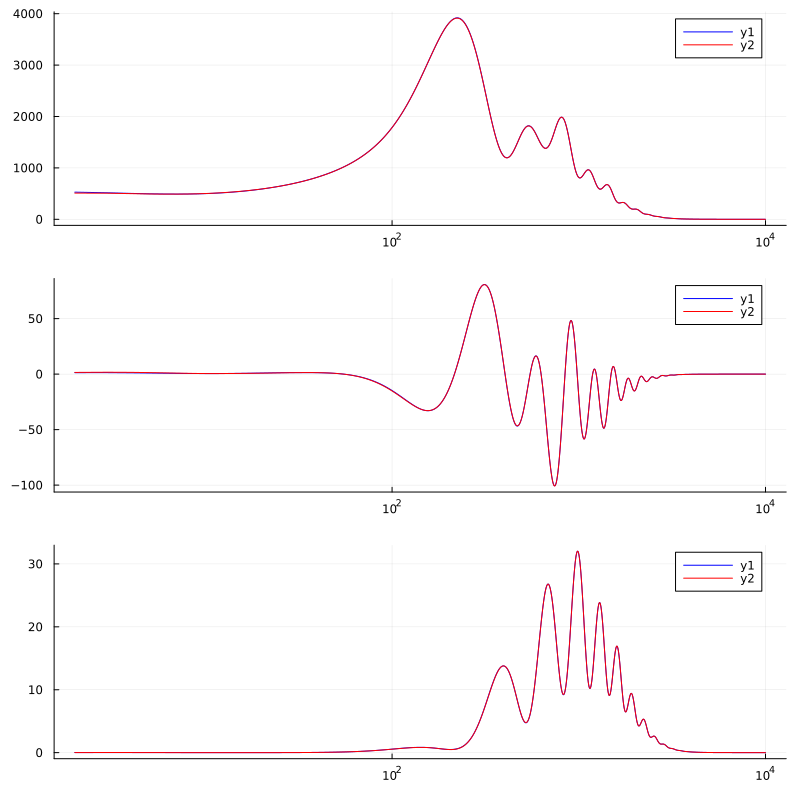

In [6]:
# Overlays the exact and emulator predictions
p1=plot(l_vec, Capse.get_Cℓ(emulator_input, TT_emu), xscale=:log10, color=:blue)
plot!(l_vec, tt, color=:red)
p2=plot(l_vec, Capse.get_Cℓ(emulator_input, TE_emu), xscale=:log10, color=:blue)
plot!(l_vec, te, color=:red)
p3=plot(l_vec, Capse.get_Cℓ(emulator_input, EE_emu), xscale=:log10, color=:blue)
plot!(l_vec, ee, color=:red)
plot(p1, p2, p3, layout=(3,1), size=(800, 800))

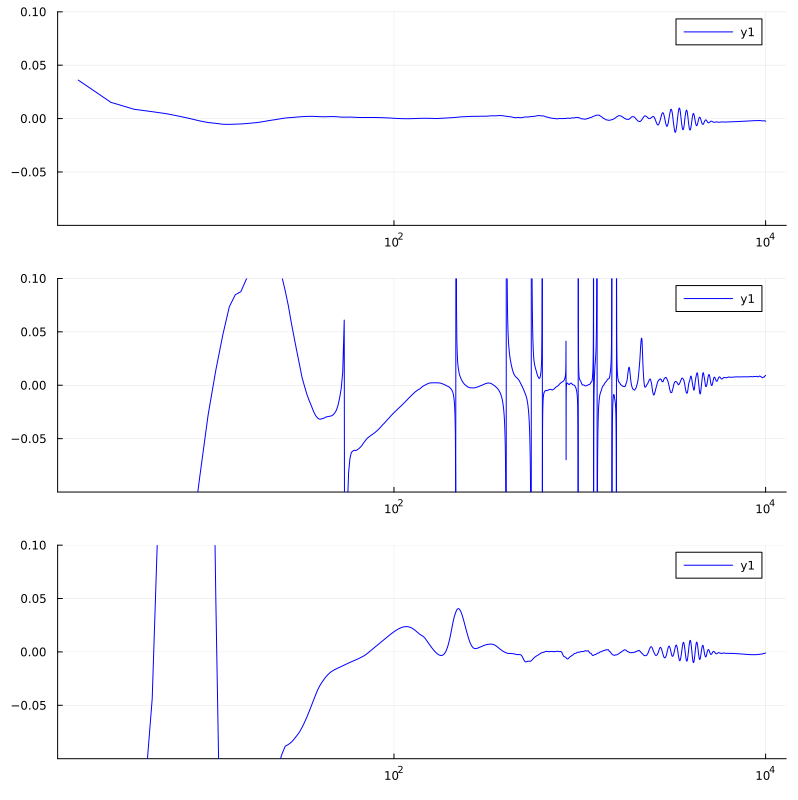

In [7]:
# Plots the fractional percentage difference between the two (this emulator has much fewer samples and is not very accurate)
diff_tt = (Capse.get_Cℓ(emulator_input, TT_emu) .- tt) ./ tt
diff_te = (Capse.get_Cℓ(emulator_input, TE_emu) .- te) ./ te
diff_ee = (Capse.get_Cℓ(emulator_input, EE_emu) .- ee) ./ ee
p1 = plot(l_vec, diff_tt, xscale=:log10, color=:blue, ylim=(-0.1,0.1))
p2 = plot(l_vec, diff_te, xscale=:log10, color=:blue, ylim=(-0.1,0.1))
p3 = plot(l_vec, diff_ee, xscale=:log10, color=:blue, ylim=(-0.1,0.1))
plot(p1, p2, p3, layout=(3,1), size=(800,800))